In [1]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

cmap = matplotlib.colormaps.get_cmap('magma')
size=15
params = {'legend.fontsize': 'large',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size,
          'ytick.labelsize': size,
          'axes.titlepad': 5,
          'lines.linewidth': 2,
          'figure.dpi': 100}
plt.rcParams.update(params)

from SVD_analysis.src.alpha_model_functions import alpha_model_w_front, tb, alpha


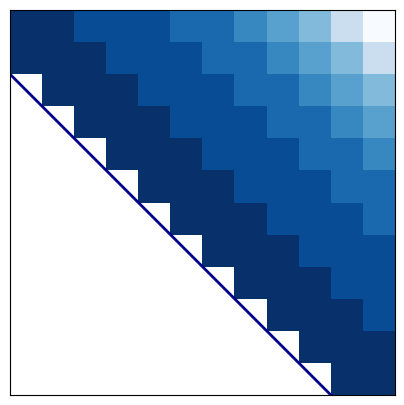

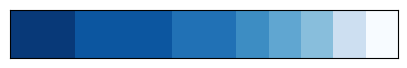

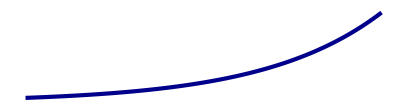

In [2]:

nx = 12
nt = 12
t = np.linspace(0, nt, nt+1)
x = np.linspace(0, nx, nx+1)-(nx-1)
tt, xx = np.meshgrid(t, x, indexing='xy')

x_psm = xx + tt
beta = 0.25
exp = (np.exp(beta*x_psm) - 1)
step = np.max(exp)/9
exp = np.round(exp/step) * step

exp[x_psm <= 0] = np.nan
plt.figure(figsize=(5,5))
plt.imshow(exp, cmap='Blues_r', origin='lower')
plt.plot(t-0.5, -x+0.5, c='darkblue')

plt.xlim((0.5, nt+0.5))
plt.ylim((0.5, nx+0.5))
plt.xticks([])
plt.yticks([])
plt.show()

plt.figure(figsize=(5,1))

plt.imshow(exp[-1, np.newaxis], cmap='Blues_r', origin='lower', aspect=1.5, vmin=-1)
plt.xlim((0.5, nt+0.5))
plt.xticks([])
plt.yticks([])
plt.show()


t = np.linspace(0, nt, 101)
plt.figure(figsize=(5,1.2))

plt.plot(np.exp(beta*t)-1, c='darkblue', lw=3)
plt.axis('off')
plt.show()

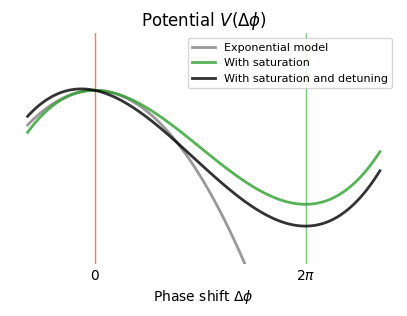

In [3]:
plt.figure(figsize=(5, 3))
xx = np.linspace(-2,8.5, 101)

a = 0.03
A = 2*np.pi
eps = 0.012

plt.vlines(0, -1, 1, color='tab:red', linestyle='-', lw=1., alpha=0.6)
plt.vlines(2*np.pi, -1, 1, color='tab:green', linestyle='-', lw=1., alpha=0.6)


yy = - a*xx**2/2
plt.plot(xx, yy, lw=2, alpha=0.8, color='grey', label='Exponential model')

yy = - a * xx**2 /2 + a/A * xx**3 /3
plt.plot(xx, yy, lw=2., alpha=0.8, color='tab:green', label='With saturation')

yy = - (a - eps/A) *xx**2/2 + a/A * xx**3/3 - eps* xx
plt.plot(xx, yy, lw=2, alpha=0.8, color='k', label='With saturation and detuning')

# yy = (-1-np.cos(2*np.pi*xx/A)) * a*A**2/12

# ________




plt.legend(frameon=True, fontsize=8)
plt.ylim(bottom=-0.3, top=0.1)
plt.xticks((0, A), labels=('0', '$2\pi$'), fontsize=10)

ax = plt.gca()
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.yaxis.set_visible(False)



ax.tick_params(axis='x', length=0)
plt.xlabel('Phase shift $\Delta \phi$', fontsize=10)
plt.title('Potential $V(\Delta \phi$)', fontsize=12)
plt.show()

# Chronic simulation (Segment/PSM)

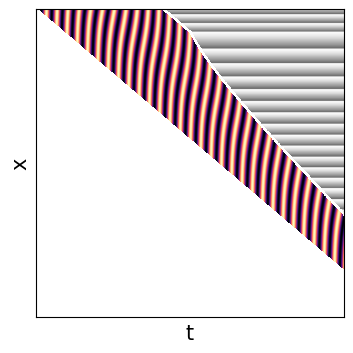

29


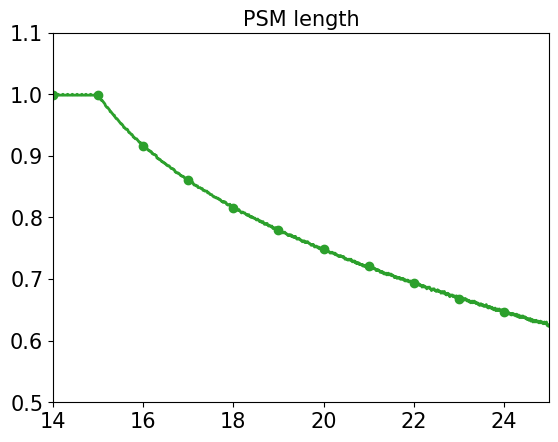

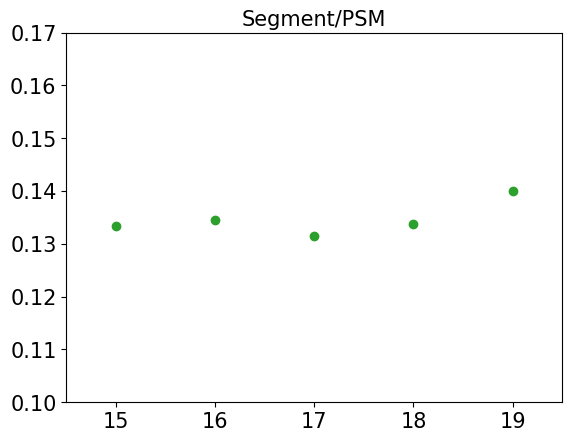

In [4]:
# using 27 chronic parameters

omega0 = 0.075
T0 = 2*np.pi/omega0
v0 = 0.17 * 4
alpha0 = 0.006

epsilon0 = alpha0 * 0.2
xmax = 500 * 4
tmax = 30*T0
timesteps = 2001


omega_pars = {
    'mode': 'const',
    'omega0': omega0,
}

alpha_pars = {
    'mode': 'const',
    'alpha0': alpha0,
}

tb_pars = {
    'mode': 'const',
    'v0': v0,
    'x0': xmax
}

epsilon_pars = {
    'mode': 'const',
    'epsilon0': epsilon0,
}

delta_star_pars = {
    'mode': 'piecewise',
    'delta0': 1.9*np.pi,
    't0': 0.5*tmax,
    'slope': 0.2/ T0,
}

phi_num, tl, phi0_num, tb_loc, t = alpha_model_w_front(xmax, np.zeros(xmax), omega_pars, alpha_pars, tb_pars, epsilon_pars,
                                         delta_star_pars, hill_coeff=None, tmax = tmax, timesteps=timesteps, sigmoid=1)

plt.figure(figsize=(6,4))
plt.imshow(np.cos(phi_num), origin='lower', cmap='magma', aspect=1.)
plt.imshow(tl % (2*np.pi), origin='lower', cmap='Greys', aspect=1., alpha=0.6)
plt.xlabel('t', fontsize=15)
plt.ylabel('x', fontsize=15)
plt.xticks(())
plt.yticks(())
plt.show()

psm_length = np.sum(~np.isnan(phi_num), axis=0)
pattern = np.abs(tl[::-1, -1])
pattern = pattern[~np.isnan(pattern)]
pattern -= pattern[0]
k = np.floor(np.abs(pattern) / (2*np.pi)).astype(int)
n_blocks = k.max() + 1
print(k.max())
lengths = np.array([np.sum(k == i) for i in range(n_blocks)])


plt.plot(phi0_num/(2*np.pi), psm_length/np.max(psm_length),  c='tab:green')
plt.ylim((0.5, 1.1))
plt.xlim((14, 25))
for l in range(14, 25, 1):
    psm_l = psm_length[np.argmin(np.abs(phi0_num/(2*np.pi) - l))]
    plt.scatter(l, psm_l/np.max(psm_length), c='tab:green')
plt.title('PSM length')
plt.show()
#

for l in range(1, n_blocks, 1):
    psm_l = psm_length[np.argmin(np.abs(phi0_num/(2*np.pi) - l))]
    plt.scatter(l, lengths[l]/psm_l, c='tab:green')
plt.xlim((14.5, 19.5))
plt.ylim((0.1, 0.17))
plt.title('Segment/PSM')
plt.show()



# 6h Vs 27C - increased v_tb

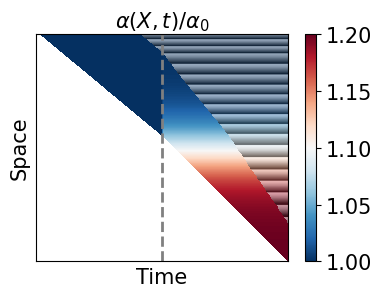

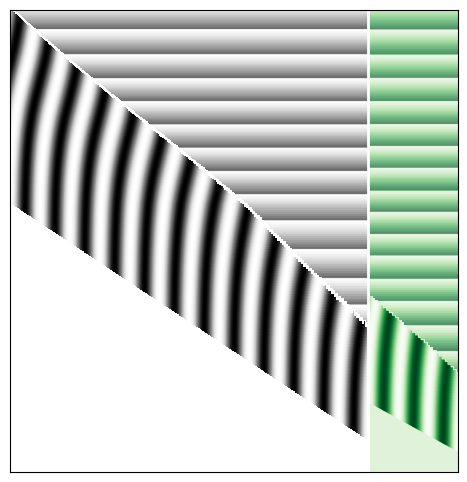

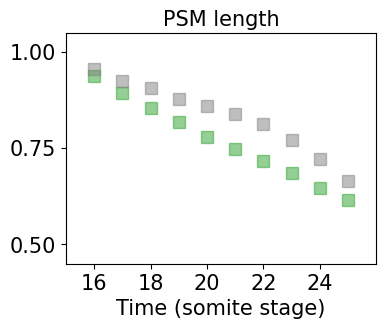

184.33333333333334
29


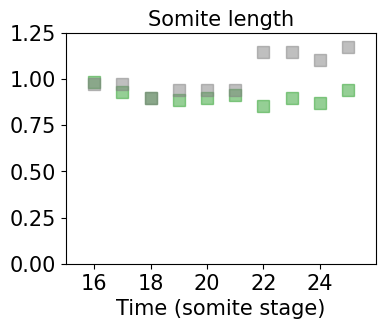

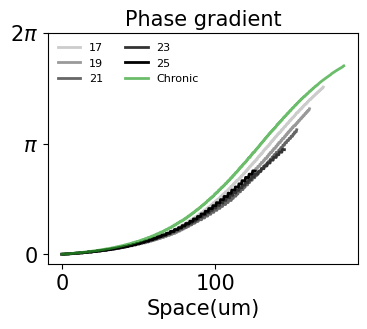

In [5]:
upscale = 3

omega0 = 0.0779
T0 = 2*np.pi/omega0
v0 = 0.127 * 1.5 * upscale
alpha0 = 0.006

epsilon0 = alpha0 * 0.1
xmax = 500 * upscale
tmax = 30*T0
timesteps = 2001


# Chronic simulation

omega_pars = {
    'mode': 'const',
    'omega0': omega0,
}

alpha_pars = {
    'mode': 'const',
    'alpha0': alpha0,
}

tb_pars = {
    'mode': 'const',
    'v0': v0,
    'x0': xmax
}

epsilon_pars = {
    'mode': 'const',
    'epsilon0': epsilon0,
}

delta_star_pars = {
    'mode': 'piecewise',
    'delta0': 1.7*np.pi,
    't0': 0.5*tmax,
    'slope': 0.3/ T0,  # 0 for plotting phase gradient
}


phi_num, tl, phi0_num, tb_loc, t = alpha_model_w_front(xmax, np.zeros(xmax), omega_pars, alpha_pars, tb_pars, epsilon_pars,
                                         delta_star_pars, hill_coeff=None, tmax = tmax, timesteps=timesteps, sigmoid=1)

# ___________________________________________________________________________________________________________________

# 6h cycle simulation

# 1) increased v_tb
tb_pars = {
    'mode': 'piecewise',
    'v1': v0*1.,
    'v2': v0*1.2,
    'x0': xmax,
    't0': 0.5*tmax,
}

#  2) alpha parameters

# A) no change

# alpha_pars = {
#     'mode': 'const',
#     'alpha0': alpha0,
# }

# B) alpha changes everywhere

# alpha_pars = {
#     'mode': 'piecewise',
#     'alpha1': alpha0,
#     'alpha2': alpha0*1.2,
#     't0': 0.5*tmax,
# }

# C) alpha changes in the posterior (new cells)

# alpha_pars = {
#     'mode': 'spatial change',
#     'alpha0': alpha0,
#     'alpha1': alpha0*1.,
#     'alpha2': alpha0*1.2,
#     't0': 0.5*tmax,
#     't1': 0.5*tmax, # 0.55
#     'tb_pars': tb_pars,
#     'len': xmax+1,
#     'L': 1*upscale,  # 40
# }


# D) alpha changes in the posterior + smooth profile

alpha_pars = {
    'mode': 'spatial change',
    'alpha0': alpha0,
    'alpha1': alpha0*1.,
    'alpha2': alpha0*1.2,
    't0': 0.5*tmax,
    't1': 0.55*tmax,
    'tb_pars': tb_pars,
    'len': xmax+1,
    'L': 40*upscale,
}


t = np.linspace(0, tmax, timesteps)
x = np.arange(xmax+1).astype('float')
tt, xx = np.meshgrid(t, x, indexing='xy')
x_tb = tb(t, tb_pars)
xx[xx<x_tb] = np.nan
alphas = np.zeros_like(xx)
for it in range(timesteps):
    alphas[:, it] = alpha(t[it], alpha_pars)
alphas[np.isnan(xx)] = np.nan


phi_num_2, tl_2, phi0_num_2, tb_loc_2, t = alpha_model_w_front(xmax, np.zeros(xmax), omega_pars, alpha_pars, tb_pars, epsilon_pars,
                                         delta_star_pars, hill_coeff=None, tmax = tmax, timesteps=timesteps, sigmoid=1)

plt.figure(figsize=(4, 3))

plt.imshow(alphas/alpha0, origin='lower', cmap='RdBu_r', aspect=1, vmin=1, vmax=1.2)
plt.xticks([])
plt.yticks([])
plt.vlines(1000, 0, xmax, color='grey', linestyle='dashed', lw=2.)
plt.title(r'$\alpha(X, t)/\alpha_0$')
plt.xlabel('Time')
plt.ylabel('Space')
plt.colorbar()
plt.imshow(tl_2 % (2*np.pi), origin='lower', cmap='Greys', aspect=1.2, alpha=0.6)
plt.tight_layout()
plt.show()


tl_plot = tl_2.copy()
phi_plot = phi_num_2.copy()
tl_plot[:, -195:] = np.nan
phi_plot[:, -195:] = np.nan
plt.figure(figsize=(6,6))

plt.imshow(np.cos(phi_plot), origin='lower', cmap='Greys_r', aspect=1.)
plt.imshow(tl_plot % (2*np.pi), origin='lower', cmap='Greys', aspect=1., alpha=0.6)

tl[:, :-200] = np.nan
phi_num_plot = phi_num.copy()
phi_num_plot[np.isnan(phi_num_plot)] = np.pi*0.25
phi_num_plot[:, :-200] = np.nan

plt.imshow(np.cos(phi_num_plot), origin='lower', cmap='Greens_r', aspect=1., alpha=1)
plt.imshow(tl % (2*np.pi), origin='lower', cmap='Greens', aspect=1., alpha=0.6)
plt.vlines(1800, 0, xmax, linestyles='solid', colors='w')
plt.xticks([])
plt.yticks([])

plt.xlim((1000, 2000))
plt.ylim((60, 1350))
ax = plt.gca()
ax.set_aspect(0.8)
plt.show()

# _______________________________________________________________________
# plt.figure(figsize=(5,3.3))
plt.figure(figsize=(4, 3))

psm_length = np.sum(~np.isnan(phi_num), axis=0)
psm_length_2 = np.sum(~np.isnan(phi_num_2), axis=0)

max_l = 26

for l in range(16, max_l, 1):
    psm_l = psm_length[np.argmin(np.abs(phi0_num/(2*np.pi) - l))]
    psm_l_2 = psm_length_2[np.argmin(np.abs(phi0_num_2/(2*np.pi) - l))]
    plt.plot(l, psm_l/np.max(psm_length), marker='s', c ='tab:green', alpha=0.5, markersize=8, lw=0)
    plt.plot(l, psm_l_2/np.max(psm_length_2), marker='s', c='gray' , alpha=0.5, markersize=8, lw=0)
plt.ylim((0.45, 1.05))
plt.yticks((0.5, 0.75, 1))
plt.xlim((15, max_l))
plt.xticks(np.arange(16, max_l, 2))
plt.title('PSM length')
plt.xlabel('Time (somite stage)')

plt.show()
print(np.max(psm_length)/upscale)

# _________________________________________________________________________
pattern = tl[::-1, -1]
pattern = pattern[~np.isnan(pattern)]
pattern -= pattern[0]

k = np.floor(np.abs(pattern) / (2*np.pi)).astype(int)
n_blocks = k.max() + 1
print(k.max())
lengths = np.array([np.sum(k == i) for i in range(n_blocks)])

norm = 23

# plt.figure(figsize=(5,3.3))
plt.figure(figsize=(4, 3))

plt.plot(np.arange(16, max_l, 1), lengths[16:max_l]/upscale/norm, lw=0, marker='s', c ='tab:green', alpha=0.5, markersize=8)

pattern = np.abs(tl_2[::-1, -1])
pattern = pattern[~np.isnan(pattern)]
pattern -= pattern[0]
k = np.floor(np.abs(pattern) / (2*np.pi)).astype(int)
n_blocks = k.max() + 1
lengths = np.array([np.sum(k == i) for i in range(n_blocks)])

plt.plot(np.arange(16, max_l, 1), lengths[16:max_l]/upscale/norm, lw=0, marker='s', c='gray' , alpha=0.5, markersize=8)
plt.xlim((15, 26))
plt.ylim((0., 1.25))
plt.xticks(np.arange(16, max_l, 2))

plt.title('Somite length')
plt.xlabel('Time (somite stage)')
plt.show()

# ______________________________________________________________


plt.figure(figsize=(4, 3))

times = np.arange(1133, 1700, 133)
colors = np.linspace(0.8, 0, len(times))
for i, it in enumerate(times):
    gradient = np.abs(phi_num_2[:, it]-phi0_num_2[it])
    gradient = gradient[~np.isnan(gradient)]
    ss = phi0_num_2[it]/2/np.pi
    plt.plot(np.arange(len(gradient))/upscale, gradient, c=str(colors[i]),
             alpha=1, label=int(np.round(ss)), lw=2)

it = 1000
gradient = np.abs(phi_num[:, it]-phi0_num[it])
gradient = gradient[~np.isnan(gradient)]
plt.plot(np.arange(len(gradient))/upscale, gradient, c='tab:green', alpha=0.7, lw=2, label='Chronic')
plt.yticks((0, np.pi, 2*np.pi), labels=('$0$', '$\pi$', '$2\pi$'))
plt.legend(fontsize=8, frameon=False, ncol=2)
plt.xlabel('Space(um)')
plt.title('Phase gradient')
plt.show()
